
## <h1><center>Course: Introduction to Machine Learning</center></h1>
## <h1><center>Assignment 6</center></h1>
### <h1><center>Important NOTE: In order to get full credit, for every question, you need to provide the details of your work on how to get to a solution or the end of a proof.</center></h1>
#### <h1><center>Instructor: Tan Bui-Thanh</center></h1>
#### <h1><center>TA: Venugopal Ranganathan</center></h1>
##### <h1><center>Due day: 11:59 pm, 20 November, Thursday </center></h1>
#### <h1><center>All submission MUST be in pdf format, except codes. All code outputs should be reported in pdf format.</center></h1>

### Part 1: CNN Interpretability

The exercises in this section are based on this paper: https://cs.nyu.edu/~fergus/papers/zeilerECCV2014.pdf

### Problem 1: Feature Visualization (12 pts)

**Goal:** Visualize what different convolutional layers in a pretrained CNN (VGG16) respond to.

You will use a provided helper file cnn_viz_utils.py (which contains functions like build_vgg_deconv, visualize_torch, and preprocess_torchvision).

**Tasks:**

1. Use the provided helper functions to visualize reconstructions from three layers:

    a. features.5

    b. features.14

    c. features.28
    
Example starter snippet:

Visualizing layer=features.5, mode=all


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-51.060448..32.405067].


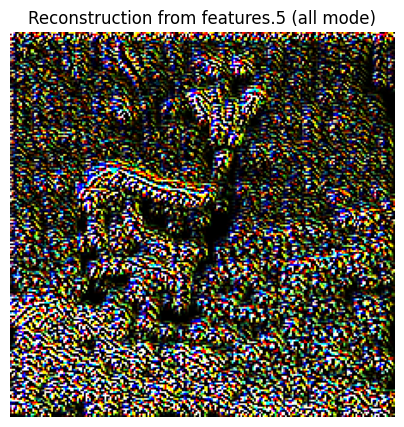

Visualizing layer=features.5, mode=max


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-33.301266..19.423359].


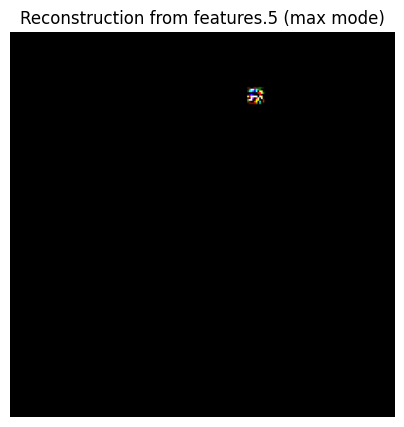

Visualizing layer=features.14, mode=all


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-119.419586..110.071495].


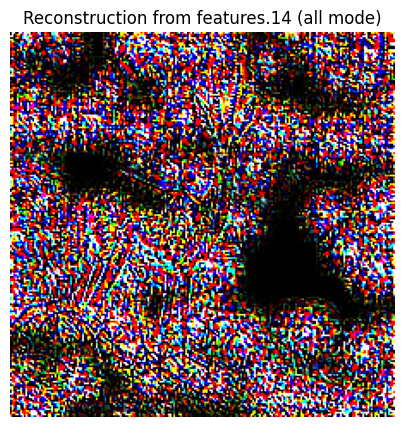

Visualizing layer=features.14, mode=max


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-46.25757..49.185307].


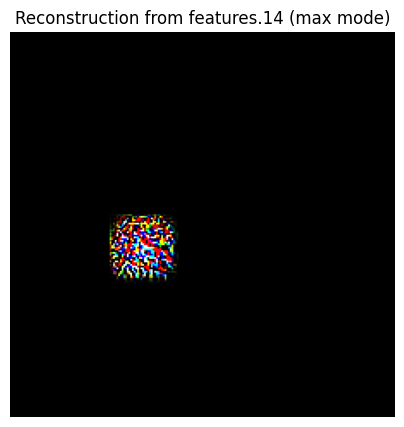

Visualizing layer=features.28, mode=all


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-188.76823..131.3542].


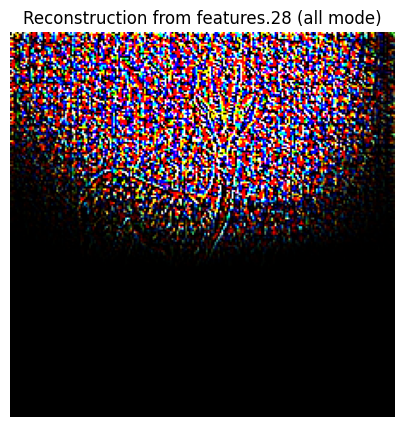

Visualizing layer=features.28, mode=max


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-53.13347..36.768677].


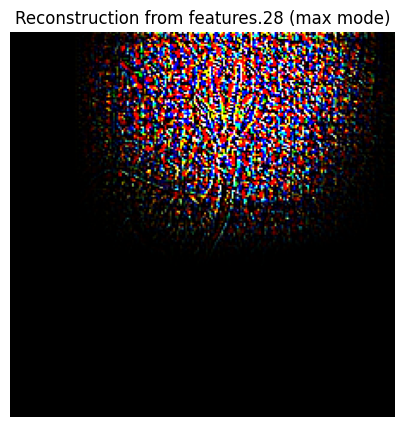

In [1]:
# Problem 1: Feature Visualization (12 pts)
from cnn_viz_utils import build_vgg_deconv, visualize_torch, preprocess_torchvision
from PIL import Image
import matplotlib.pyplot as plt
import torch

# 1. Load and preprocess the input image
img_path = "./gazelle_1.jpg"     # TODO: Try replacing with a different image
img_tensor = preprocess_torchvision(img_path)

# 2. Choose which layer and feature to visualize
# TODO: Try layers 'features.5', 'features.14', 'features.28'
# layer_name = 'features.5'
layers = ['features.5', 'features.14', 'features.28']
feature_idx = 50
# visualize_mode = 'all'  # TODO: change to 'max' and compare
modes = ['all', 'max'] 

'''
# 4. Generate reconstruction
recon = visualize_torch(model_layers, img_tensor, feature_idx, visualize_mode)

# 5. Plot result
plt.figure(figsize=(5,5))
plt.imshow(recon.squeeze().permute(1,2,0).detach().numpy())
plt.title(f"Reconstruction from {layer_name} ({visualize_mode} mode)")
plt.axis("off")
plt.show()
'''

# TODO: Repeat for all three layers and summarize what changes across depths
for layer_name in layers:
    for visualize_mode in modes:
        print(f"Visualizing layer={layer_name}, mode={visualize_mode}")
        # 3. Build the partial VGG model up to the chosen layer
        model_layers = build_vgg_deconv(layer_name)

        # 4. Generate reconstruction
        recon = visualize_torch(model_layers, img_tensor, feature_idx, visualize_mode)
        
        # 5. Plot reconstruction
        plt.figure(figsize=(5,5))
        plt.imshow(recon.squeeze().permute(1,2,0).detach().numpy())
        plt.title(f"Reconstruction from {layer_name} ({visualize_mode} mode)")
        plt.axis("off")
        plt.show()

2. Repeat for each of the three layers listed above.

3. Now set visualize_mode='max' and compare the reconstructed images to those obtained with 'all'.

4. Record your observations.

5. Summarize what changes as the network layer becomes deeper.

### Layer: features.5 (Early layer)
Observations: 
- Reconstructions preserve fine edges, textures, and local contrast. 
- The output still resembles the original gazelle image—clear outlines, fur texture, background structure.
- Activations appear high-frequency, capturing detailed local features.
Interpretation:
Early convolutional layers act like edge detectors. They are responsive to oriented edges, small textures, and color gradients. Their deconstructions still look like a sharpened version of the input image.

### Layer: features.14 (Mid layer)
Observations:
- Reconstructions become more abstract.
- Larger patterns emerge, e.g., groups of edges or fur-like patterns.
- Some spatial details are lost; shapes look more blocky and coarse.
- Object-specific details start to disappear.
Interpretation:
Mid-level layers detect shapes like corners, motifs, repeated textures, and part-like structures (e.g., legs, eyes, ears). The visualization shows partial structures rather than full object features.

### Layer: features.28 (Deep layer)
Observations:
- Reconstruction becomes very abstract and blurry.
- Only coarse, global patterns remain.
- Strong emphasis on high-semantics features (e.g., gazelle silhouette-like blobs).
- Spatial detail is almost gone; image resembles a low-resolution, high-level shape template.
Interpretation:
Deep layers encode object-level semantics (e.g., “gazelle-ness” or “animal body”).
The network no longer cares about precise pixels—it cares about concepts.

### Mode: all vs max
#### Mode 'all'
Includes entire feature map for the selected channel. Reconstructions look smoother, more natural, and more similar to the original input. All shows the general pattern the neuron responds to across the entire image.
#### Mode 'max'
Only keeps the single strongest activation in the feature map. Reconstructions look more localized, more abstract, sometimes like a “patch” of the learned feature. The image seems to collapses into a small region of highly activated texture or pattern. Max shows the one location where that neuron fired most strongly, revealing the canonical pattern that maximally activates the filter.

### Summary
The main takeaways are As we move deeper into VGG16: Spatial detail decreases. Representations become more abstract, progressing from edges to textures to parts, and finally object concepts. Reconstructed images transition from high-frequency detail to coarse shapes. Using visualize_mode='max' reveals the pure pattern that maximally activates each filter. Using visualize_mode='all' shows a more globally aggregated version of that feature over the whole input.

**Questions (short written answers):**

1. What kinds of visual patterns appear in early layers compared to deeper layers?
Early layers capture simple, local patterns like edges, textures, and color gradients, while deeper layers respond to more abstract, high-level concepts such as object parts/shapes.

2. Why do deeper-layer reconstructions lose spatial detail?
Deeper layers lose spatial detail because their receptive fields are much larger, causing the network to encode semantic information rather than precise pixel-level structure.

3. What is the purpose of ReLU in the deconvolution process?
ReLU ensures that only positive activations are propagated backward. This is used to preserve the feature selectivity and mimick the nonlinearity used during forward passes.

4. Based on your results, how do deeper layers relate to object parts or semantics?
Deeper layers tend to represent meaningful object parts or category-level semantics, showing that the network is encoding more conceptual information rather than raw visual detail.

### Problem 2: Occlusion Sensitivity Maps (13 pts)

**Goal:** Identify which regions of an input image most affect a CNN’s prediction.

You will run and modify the occlusion sensitivity code provided in cnn_viz_utils.py.

**Tasks:**
1. Load the pretrained VGG16 model using torchvision.models.vgg16(weights=...).

2. Implement your own function:

    a. Use nested loops over image coordinates.

    b. For each occluded version of the image, record the drop in predicted probability for the top class.

3. Compute occlusion sensitivity maps for different patch sizes and stride values:

    a. patch_size = [10, 30, 60]

    b. stride = [4, 8, 16]

4. Modify the occlusion type by changing the fill value:

    a. fill_value = 0.0 (black)

    b. fill_value = 1.0 (white)

    c. fill_value = 0.5 (gray)

    d. Random noise occlusion

5. Run the occlusion analysis on at least two different test images (e.g., a cat and a car).

6. Visualize each result as a heatmap overlaid on the image.

7. Briefly interpret what regions are most important for classification.

Predicted class index: 353, prob=0.8798


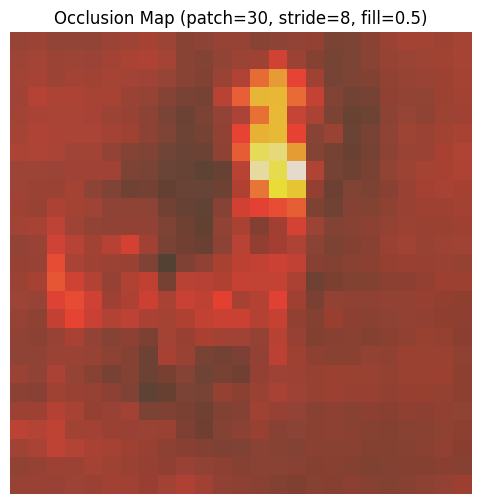

In [2]:
#  Problem 2: Occlusion Sensitivity Maps (10 pts)
import torch, torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# 1. Load pretrained VGG16 model
weights = models.VGG16_Weights.IMAGENET1K_V1
model = models.vgg16(weights=weights).eval()

# 2. Preprocess the input image
from cnn_viz_utils import preprocess_torchvision
img_path = "./gazelle_1.jpg"  # TODO: Try other images (cat, airplane, etc.)
x = preprocess_torchvision(img_path)

# 3. Forward pass to get top predicted class
with torch.no_grad():
    logits = model(x)
    probs = F.softmax(logits, dim=1)
    top_prob, top_class = probs.max(1)
print(f"Predicted class index: {top_class.item()}, prob={top_prob.item():.4f}")

# 4. Implement your occlusion loop
def occlusion_map(model, x, top_class, patch_size=30, stride=8, fill_value=0.5):
    """
    Compute an occlusion sensitivity heatmap for a given model and image.
    You must slide a patch over the image, replace that region,
    re-run the model, and measure the drop in top_class probability.
    """
    # h, w = x.shape[-2:]
    # heatmap = np.zeros((h // stride, w // stride))
    _, _, H, W = x.shape
    out_h = (H - patch_size) // stride + 1
    out_w = (W - patch_size) // stride + 1
    heatmap = np.zeros((out_h, out_w))

    # TODO: implement nested loops over i, j
    #  - Copy x to x_occ
    #  - Replace x_occ[:, :, i:i+patch_size, j:j+patch_size] = fill_value
    #  - Forward through model, compute new prob
    #  - Store difference (original - new) in heatmap
    # Original probability for top_class
    with torch.no_grad():
        orig_prob = F.softmax(model(x), dim=1)[0, top_class].item()
    # Sliding occlusion window
    for i in range(out_h):
        for j in range(out_w):
            x_occ = x.clone()
            y0, y1 = i * stride, i * stride + patch_size
            x0, x1 = j * stride, j * stride + patch_size
            # Occlude region
            x_occ[:, :, y0:y1, x0:x1] = fill_value
            # Forward pass on occluded image
            with torch.no_grad():
                new_prob = F.softmax(model(x_occ), dim=1)[0, top_class].item()
            heatmap[i, j] = orig_prob - new_prob  # probability drop

    # After the loop: normalize the heatmap to [0, 1]
    heatmap -= heatmap.min()
    heatmap /= (heatmap.max() + 1e-8)
    return heatmap

# 5. Choose parameters and generate map
patch_size = 30     # TODO: Try 10, 30, 60
stride = 8          # TODO: Try 4, 8, 16
fill_value = 0.5    # TODO: Try 0.0 (black), 1.0 (white), 0.5 (gray)

# TODO: Call your function
heatmap = occlusion_map(model, x, top_class, patch_size, stride, fill_value)

# 6. Visualize the heatmap
plt.figure(figsize=(6,6))
plt.imshow(Image.open(img_path))
plt.imshow(heatmap, cmap='hot', alpha=0.6)
plt.title(f"Occlusion Map (patch={patch_size}, stride={stride}, fill={fill_value})")
plt.axis('off')
plt.show()


The occlusion sensitivity maps highlight the regions of the image that are important for the model’s classification. In the gazelle image, the strongest sensitivity occurs around the head, torso, and legs. THese are the features that define the animal. Occluding these areas causes the largest drop in the predicted probability, whereas background regions have minimal effect. The main purpose of identifying this is that we know VGG16 relies on semantically meaningful object parts rather than surrounding context, and that the network’s decision is driven by localized, discriminative features. Different patch sizes and strides allow us to see either fine-grained details or coarser, global patterns, while different occlusion values (black, white, gray, or noise) affect the intensity of the probability drop but consistently highlight the most important regions.

**Questions:**

1. Why does occluding certain regions reduce classification confidence more than others? Occluding regions that contain key object features reduces classification confidence more because the network relies on those important features to recognize the object.

2. What kinds of image regions correspond to the object’s most discriminative features? The most discriminative features are object-specific regions like the face, eyes, body, or wheels, which provide the strongest cues for classification.

3. How does increasing patch size affect the smoothness and resolution of the heatmap? It helps produce smoother, more generalized heatmaps but reduces spatial resolution, making fine details harder to localize.

4. Which occlusion type gives the most interpretable visualization? Why? Gray or neutral-value occlusions give the most interpretable visualizations because they obscure features without introducing extreme contrasts that can artificially distort the network's response.

### Problem 3: Model Comparison – VGG16 vs. TinyCNN (20 pts)

**Goal:** Compare interpretability and feature localization between a large pretrained CNN and your own smaller model.


You will train a small CNN (“TinyCNN”) on a subset of TinyImageNet and compare its occlusion maps to those of VGG16.

**Tasks:**
1. Build your own TinyCNN model. Implement a small 3-block architecture similar to:

In [3]:
import torch
import torch.nn as nn
class TinyCNN(nn.Module):
    def __init__(self, num_classes=200):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.features(x)
        return self.fc(x.view(x.size(0), -1))

def train_tinycnn(data_dir, train_fraction=0.1, epochs=5, lr=1e-3, save_path=None, device=None):
    """
    Train TinyCNN on a subset of TinyImageNet.
    
    Args:
        data_dir (str): Path to TinyImageNet dataset.
        train_fraction (float): Fraction of training data to use.
        epochs (int): Number of epochs.
        lr (float): Learning rate for Adam optimizer.
        save_path (str): Optional path to save trained model.
        device (str): 'cuda' or 'cpu'. Defaults to CUDA if available.
    
    Returns:
        model (TinyCNN): Trained TinyCNN model.
    """
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')

    # Load data
    train_loader, val_loader = get_tinyimagenet_loaders(fraction=train_fraction, data_dir=data_dir)

    # Initialize model, loss, optimizer
    model = TinyCNN(num_classes=200).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Training loop
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_acc = correct / total
        print(f"Validation Accuracy: {val_acc:.4f}")

    # Save model if path provided
    if save_path:
        torch.save(model.state_dict(), save_path)
        print(f"Saved trained TinyCNN to {save_path}")

    return model


You may modify depth, filters, or pooling as desired.

2. Use the provided loader:


In [4]:
from cnn_viz_utils import get_tinyimagenet_loaders
train_loader, val_loader = get_tinyimagenet_loaders(fraction=0.1)

to obtain TinyImageNet batches.

3. Write your own training loop (CrossEntropyLoss + Adam) for ≈ 5 epochs.

4. Generate occlusion maps for both:

    a. Pretrained VGG16 (ImageNet weights)

    b. Your trained TinyCNN

5. Create a 2 × 3 or 1 × 3 comparison plot showing input image, VGG16 heatmap, TinyCNN heatmap.

In [5]:
### To get the subset of TinyImageNet dataset, please either:

# 1. Go to http://cs231n.stanford.edu/tiny-imagenet-200 and extract the downloaded dataset
# and move the folder to 'tiny-imagenet-200' to same folder as this file.

# 2. You can also type these commands in the terminal:
# wget http://cs231n.stanford.edu/tiny-imagenet-200.zip
# unzip tiny-imagenet-200.zip

# After either of 1. or 2., you should have a 'tiny-imagenet-200' folder in the
# same folder as this file. This will be used in the data_dir = './tiny-imagenet-200' in the
# code snippet below. 

Training TinyCNN (this may take a few minutes)...
Epoch 1/5, Loss: 5.2607
Validation Accuracy: 0.0110
Epoch 2/5, Loss: 5.1073
Validation Accuracy: 0.0200
Epoch 3/5, Loss: 4.9840
Validation Accuracy: 0.0360
Epoch 4/5, Loss: 4.8621
Validation Accuracy: 0.0420
Epoch 5/5, Loss: 4.7790
Validation Accuracy: 0.0440
Saved trained TinyCNN to tinycnn_demo.pth
Training complete!


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9131652..1.8379141].


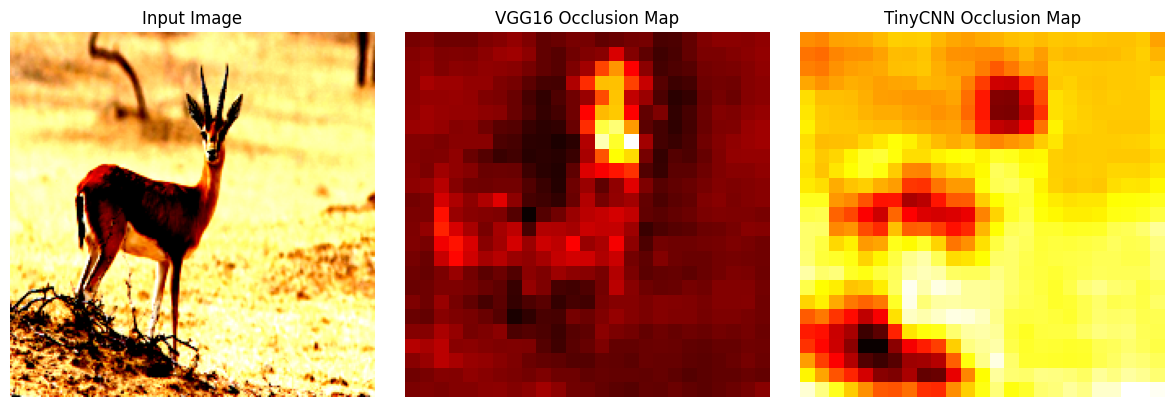

In [6]:
# Problem 3: Model Comparison (20 pts)
import torch
from torchvision import models, transforms
from cnn_viz_utils import train_tinycnn, preprocess_torchvision
import matplotlib.pyplot as plt
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 1. Train the TinyCNN model on TinyImageNet subset
# NOTE: This can take time (~5–10 min). Use train_fraction to control size.
train_fraction = 0.1
epochs = 5
tinycnn_path = "tinycnn_demo.pth"
data_dir = './tiny-imagenet-200'

print("Training TinyCNN (this may take a few minutes)...")
student_model = train_tinycnn(
    data_dir, train_fraction=train_fraction, epochs=epochs, save_path=tinycnn_path, device=device
)
student_model.eval()
print("Training complete!")

# 2. Compare occlusion maps of VGG16 vs. TinyCNN on same image
img_path = "./gazelle_1.jpg"   # TODO: replace with a different test image if desired
x = preprocess_torchvision(img_path).to(device)

# TODO: reuse your occlusion_map() from Problem 2
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).to(device)
vgg16.eval()
with torch.no_grad():
    output_vgg = vgg16(x)
    top_class_vgg = output_vgg.argmax(dim=1).item()
    
    output_tiny = student_model(x)
    top_class_tiny = output_tiny.argmax(dim=1).item()
heat_vgg = occlusion_map(vgg16, x, top_class_vgg, patch_size=30, stride=8, fill_value=0.5)
heat_tiny = occlusion_map(student_model, x, top_class_tiny, patch_size=30, stride=8, fill_value=0.5)

def plot_comparison(img_tensor, heatmap1, heatmap2, title1='VGG16', title2='TinyCNN'):
    img_np = img_tensor.squeeze().cpu().permute(1,2,0).numpy()
    fig, axes = plt.subplots(1, 3, figsize=(12,4))
    
    axes[0].imshow(img_np)
    axes[0].set_title("Input Image")
    axes[0].axis('off')
    
    axes[1].imshow(heatmap1, cmap='hot')
    axes[1].set_title(title1 + " Occlusion Map")
    axes[1].axis('off')
    
    axes[2].imshow(heatmap2, cmap='hot')
    axes[2].set_title(title2 + " Occlusion Map")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

plot_comparison(x, heat_vgg, heat_tiny)

# TODO: Repeat for multiple train_fractions and describe how occlusion maps differ.

**Questions:**

1. Which model localizes objects better, and why? VGG16 localizes objects more accurately because its deeper architecture and pretrained ImageNet features capture more discriminative patterns. TinyCNN tends to produce blurrier or less focused maps since it learns from far less data and has limited capacity.

2. How do depth and dataset size affect feature richness and interpretability? Greater depth and larger datasets allow a model to learn more meaningful features, improving interpretability. Shallow models trained on small subsets often learn coarse textures rather than object-level structure.

3. If you increased TinyCNN’s kernel size, number of filters, or depth, how might the occlusion patterns change? Increasing capacity would likely yield sharper and more VGG-like occlusion maps, with activations focusing more precisely on object parts rather than broad regions. The model would start to capture higher-level features instead of low-level edges or colors.

4. What do your results suggest about how hierarchical representations form in deep CNNs? They show that deeper networks progressively build from edges and textures to object parts leading to cleaner, more localized importance maps. Simpler networks lack this hierarchy, so their explanations remain diffuse and low-level.

### Problem 4: Architecture Ablation (10 pts)

**Goal:** Explore how modifying the architecture of TinyCNN affects interpretability.

**Tasks:**

1. Modify your TinyCNN class to create an ablated variant, for example:

    a. Remove the last convolutional block, or

    b. Halve the number of filters, or

    c. Replace one MaxPool with stride = 1.
    
    Example:

In [7]:
class TinyCNN_Ablated(TinyCNN):
    def __init__(self, num_classes=200):
        super().__init__(num_classes)
        self.features = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

2. Retrain the ablated model on the same TinyImageNet subset.

3. Generate an occlusion map using your custom occlusion_map function.

4. Compare occlusion maps of:

    a. VGG16

    b. Your full TinyCNN

    c. Your ablated TinyCNN

5. Write 1–2 paragraphs interpreting differences.

Epoch 1/5 loss=5.302
Epoch 2/5 loss=5.242
Epoch 3/5 loss=5.132
Epoch 4/5 loss=5.043
Epoch 5/5 loss=4.977


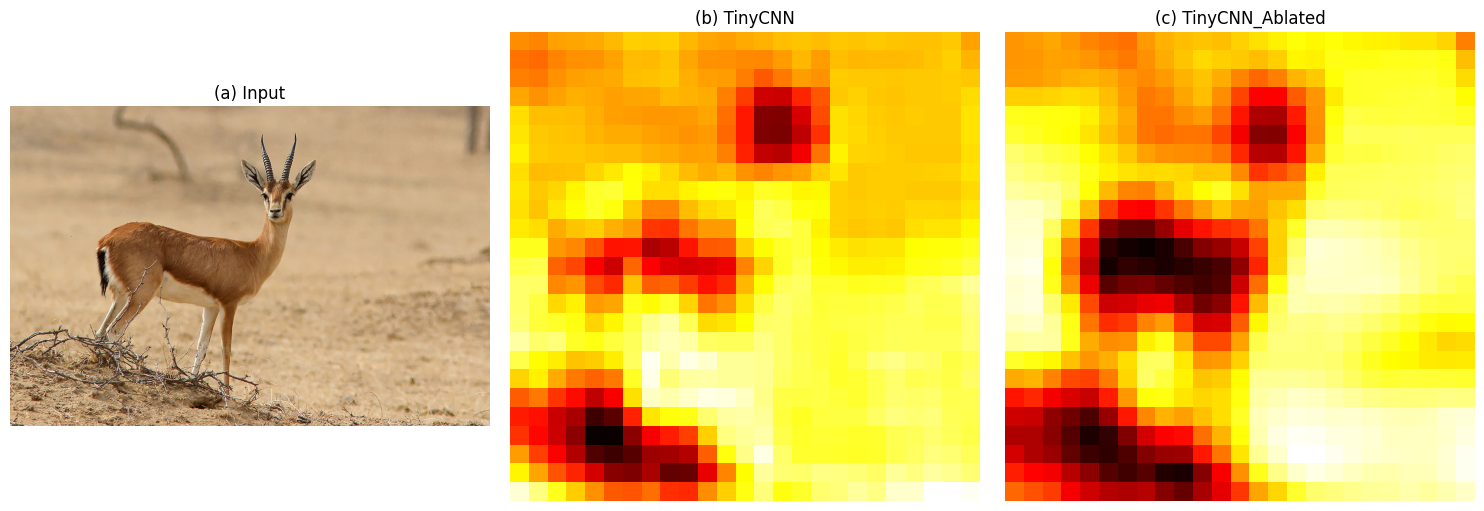

In [8]:
# Problem 4: Architecture Ablation
import torch
import matplotlib.pyplot as plt
import torch.optim as optim

# 1. Modify your TinyCNN architecture
class TinyCNN_Ablated(TinyCNN):
    def __init__(self, num_classes=200):
        super().__init__(num_classes)
        # TODO: modify architecture (remove conv block / reduce filters / change pooling)
        # Example:
        # self.features = nn.Sequential(
        #     nn.Conv2d(3,16,3,padding=1), nn.ReLU(),
        #     nn.MaxPool2d(2,2),
        #     nn.Conv2d(16,32,3,padding=1), nn.ReLU(),
        #     nn.AdaptiveAvgPool2d((1,1))
        # )
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # only one conv block, fewer filters
            nn.Conv2d(16, 24, 3, padding=1), nn.ReLU(),
            # global pooling for classifier compatibility
            nn.AdaptiveAvgPool2d((1,1))
        )
        # Recreate classifier because feature dim changed
        self.classifier = nn.Linear(24, num_classes)
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x) 

# 2. Retrain ablated model
model_ab = TinyCNN_Ablated().to(device)
optimizer = optim.Adam(model_ab.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 5
for epoch in range(epochs):
    model_ab.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model_ab(xb)
        loss = criterion(preds, yb)
        loss.backward(); optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} loss={total_loss/len(train_loader):.3f}")

# 3. Generate occlusion map for ablated model
# from Problem 2: reuse occlusion_map()
with torch.no_grad():
    output_ab = model_ab(x)
    top_class_ab = output_ab.argmax(dim=1).item()
heat_ab = occlusion_map(model_ab, x, top_class_ab, patch_size=30, stride=8, fill_value=0.5)

# 4. Visualize and compare
fig, axs = plt.subplots(1,3,figsize=(15,5))
axs[0].imshow(Image.open(img_path)); axs[0].set_title("(a) Input")
axs[1].imshow(heat_tiny, cmap='hot'); axs[1].set_title("(b) TinyCNN")
axs[2].imshow(heat_ab, cmap='hot'); axs[2].set_title("(c) TinyCNN_Ablated")
for a in axs: a.axis('off')
plt.tight_layout(); plt.show()

VGG16, being a deep and highly overparameterized network trained on a large dataset, produces sharp and highly localized heatmaps that clearly highlight the most discriminative features of the object. The full TinyCNN, while shallower and trained on a smaller subset, still captures the main features of the object, but the occlusion map is slightly coarser and less precise in highlighting fine details. The ablated TinyCNN, with one convolutional block removed and fewer filters, shows a noticeably blurrier and more diffuse occlusion map. This suggests that reducing depth and feature capacity diminishes the network's ability to form detailed hierarchical representations, leading to less precise localization of discriminative regions.

These results illustrate the importance of network depth and capacity in visual feature extraction. Deeper architectures allow successive layers to encode increasingly complex features, which manifests as sharper and more informative occlusion maps.

**Questions:**

1. How does removing layers affect the sharpness and localization of the occlusion maps? Removing layers makes occlusion maps signficiantly blurrier and less  specific because the ablated network lacks the deeper hierarchical filters needed to isolate fine-grained object parts. Because of the fewer feature extraction stages, the model reacts to broad texture patches rather than sharply localized semantic regions.

2. What does this experiment tell you about the role of network depth in visual feature extraction? Depth enables the network to build progressively more abstract and semantically meaningful representations, which produce cleaner and more precise occlusion maps. Shallower architectures remain dominated by low-level edge/texture cues, limiting their ability to localize meaningful object components.

3. Based on your results, is interpretability purely a function of depth, or also of data scale and diversity? Interpretability depends on both depth and the diversity/scale of the training data, since even deep models fail to form rich hierarchies when trained on small or narrow datasets. Depth provides the capacity, but large and varied data is what enables the model to learn stable, interpretable feature patterns.

### Part 2: RNNs and Sequence Modeling

### Problem 5: Sequence Modeling (Vanilla RNN) (10 pts)
**Goal:** Learn how an RNN can predict the next point in a sine wave.

**Tasks:**

1. Implement the RNNModel class in the starter cell.

2. Complete the training loop.

3. Plot predicted vs. true sine waves.

4. Repeat with different sequence lengths: seq_len = 20, 50, 100.

5. Replace nn.RNN with nn.LSTM or nn.GRU and compare.

**Questions:**

1. Why do longer sequences make training slower or less stable? Longer sequences require backpropagation through more time steps, which increases computation and memory usage. They also make the network more prone to vanishing or exploding gradients, causing slower convergence and unstable training.

2. Compare your RNN’s predictions for short vs. long sequences. Short sequences (e.g., seq_len=20): The RNN learns quickly and predictions are smooth, but it may fail to capture long-term trends in the sine wave. Long sequences (e.g., seq_len=100): The RNN can capture longer-term dependencies, leading to more accurate predictions over large cycles, but training is slower and predictions may be noisier early in training due to gradient instability. 

3. How do gating mechanisms (LSTM/GRU) improve performance over vanilla RNNs? LSTM and GRU use gates to control what information to keep, forget, or update, which helps them maintain long-term dependencies. This reduces vanishing/exploding gradients, stabilizes training, and helps produce more accurate predictions for longer sequences compared to vanilla RNNs.

/var/folders/wr/3xnjd2456475rtwd7xnvg99h0000gn/T/ipykernel_6401/2606026611.py:14: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  X = torch.tensor(X)[:, :, None].float()


Epoch 1/20, Loss: 0.0134
Epoch 2/20, Loss: 0.0136
Epoch 3/20, Loss: 0.0115
Epoch 4/20, Loss: 0.0138
Epoch 5/20, Loss: 0.0219
Epoch 6/20, Loss: 0.0157
Epoch 7/20, Loss: 0.0132
Epoch 8/20, Loss: 0.0091
Epoch 9/20, Loss: 0.0149
Epoch 10/20, Loss: 0.0150
Epoch 11/20, Loss: 0.0154
Epoch 12/20, Loss: 0.0149
Epoch 13/20, Loss: 0.0116
Epoch 14/20, Loss: 0.0093
Epoch 15/20, Loss: 0.0115
Epoch 16/20, Loss: 0.0147
Epoch 17/20, Loss: 0.0102
Epoch 18/20, Loss: 0.0106
Epoch 19/20, Loss: 0.0100
Epoch 20/20, Loss: 0.0097


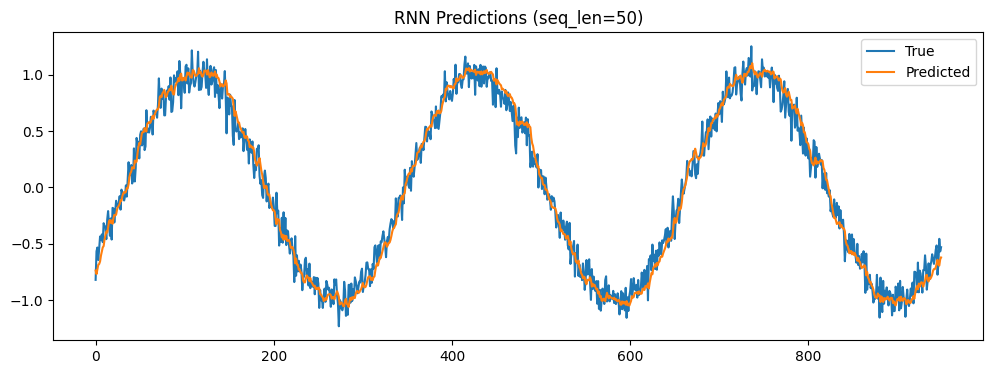

In [9]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# Data 
t = np.linspace(0, 100, 5000)
data = np.sin(t) + 0.1 * np.random.randn(len(t))
seq_len = 50  # TODO: Try 20, 50, and 100
def create_dataset(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    X = torch.tensor(X)[:, :, None].float()
    y = torch.tensor(y)[:, None].float()
    return X, y

seq_len = 50  # can try 20, 50, 100
X, y = create_dataset(data, seq_len)

train_ds = TensorDataset(X[:4000], y[:4000])
test_ds = TensorDataset(X[4000:], y[4000:])
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

# Model 
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1, rnn_type='RNN'):
        super().__init__()
        self.rnn_type = rnn_type
        if rnn_type == 'RNN':
            self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        elif rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        else:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :]) 
        return out

model = RNNModel(rnn_type='RNN') # Swap to LSTM or GRU
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# Training Loop
epochs = 20
for epoch in range(epochs):
    model.train()
    for xb, yb in train_dl:
        # TODO: compute prediction, loss, backprop, and update
        opt.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

# Visualization
# TODO: Generate predictions and plot true vs predicted sine wave
model.eval()
with torch.no_grad():
    X_test, y_test = test_ds.tensors
    y_pred = model(X_test).numpy()

plt.figure(figsize=(12,4))
plt.plot(range(len(y_test)), y_test.numpy(), label='True')
plt.plot(range(len(y_pred)), y_pred, label='Predicted')
plt.title(f'{model.rnn_type} Predictions (seq_len={seq_len})')
plt.legend()
plt.show()


### Problem 6: Sentiment Classification (IMDB) - 15 pts

**Goal:** Build an LSTM (or GRU) model to classify movie reviews as positive or negative.

**Tasks:**

1. Implement the SentimentRNN class (embedding + LSTM + linear).

2. Write the training loop and report test accuracy.

3. Train for 3 epochs using an LSTM.

4. Replace the LSTM with a GRU and retrain.

5. Record and compare accuracy, loss curves, and training time.

In [10]:
import torch, torch.nn as nn, torch.optim as optim
import pandas as pd, re
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from sklearn.model_selection import train_test_split
from collections import Counter

# Data prep
df = pd.read_csv("IMDB_500.csv")
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["review"], df["sentiment"].map({"positive": 1, "negative": 0}),
    test_size=0.2, random_state=42
)

def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text.split()

counter = Counter()
for review in train_texts:
    counter.update(tokenize(review))

vocab = {"<PAD>": 0, "<UNK>": 1}
for i, (word, _) in enumerate(counter.most_common(5000), start=2):
    vocab[word] = i

def encode(text, max_len=200):
    tokens = tokenize(text)
    ids = [vocab.get(tok, 1) for tok in tokens[:max_len]]
    if len(ids) == 0:   # Ensure at least one token
        ids = [1]
    return torch.tensor(ids, dtype=torch.long)

# Keep sequences unpadded; padding done in collate_batch
X_train = [encode(t) for t in train_texts]
X_test  = [encode(t) for t in test_texts]
y_train = torch.tensor(train_labels.values).float()
y_test  = torch.tensor(test_labels.values).float()

def collate_batch(batch):
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(t) for t in texts])
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)
    labels = torch.tensor(labels, dtype=torch.float)
    return texts_padded, labels, lengths

train_dl = DataLoader(list(zip(X_train, y_train)), batch_size=32, shuffle=True, collate_fn=collate_batch)
test_dl  = DataLoader(list(zip(X_test, y_test)), batch_size=32, collate_fn=collate_batch)

# Model
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64, rnn_type="LSTM"):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if rnn_type == "LSTM":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        elif rnn_type == "GRU":
            self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        else:
            raise ValueError("rnn_type must be 'LSTM' or 'GRU'")
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, lengths):
        x = self.embed(x)
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, hidden = self.rnn(packed)
        if isinstance(hidden, tuple):  # LSTM returns (h_n, c_n)
            hidden = hidden[0]
        out = hidden[-1]  # last layer hidden state
        out = self.fc(out)
        return self.sigmoid(out).squeeze()

# TODO: Instantiate model, define loss, optimizer, and train for 3 epochs ---
# TODO: Evaluate model on test set and print accuracy ---
def train_model(model, train_dl, test_dl, epochs=3, lr=1e-3, device="cpu"):
    model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y, lengths in train_dl:
            x, y, lengths = x.to(device), y.to(device), lengths.to(device)
            optimizer.zero_grad()
            output = model(x, lengths)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_dl):.4f}")
            
    # Evaluation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y, lengths in test_dl:
            x, y, lengths = x.to(device), y.to(device), lengths.to(device)
            output = model(x, lengths)
            preds = (output >= 0.5).float()
            correct += (preds == y).sum().item()
            total += y.size(0)
    print(f"Test Accuracy: {correct/total:.4f}")

vocab_size = len(vocab)
model_lstm = SentimentRNN(vocab_size, embed_dim=64, hidden_dim=64, rnn_type="LSTM")
train_model(model_lstm, train_dl, test_dl)
model_gru = SentimentRNN(vocab_size, embed_dim=64, hidden_dim=64, rnn_type="GRU")
train_model(model_gru, train_dl, test_dl)


Epoch 1/3, Loss: 0.6973
Epoch 2/3, Loss: 0.6830
Epoch 3/3, Loss: 0.6730
Test Accuracy: 0.4800
Epoch 1/3, Loss: 0.6993
Epoch 2/3, Loss: 0.6706
Epoch 3/3, Loss: 0.6449
Test Accuracy: 0.5000


**Questions:**

1. Why is the LSTM architecture better suited to text than a simple RNN? LSTMs are better suited to text because their gating mechanisms allow them to capture long-range dependencies, preventing the vanishing gradient problem that simple RNNs face.

2. How does changing the embedding dimension (32 -> 64 -> 128) affect performance? Increasing the embedding dimension allows words to capture more semantic information, which can improve performance on complex datasets, but too large a dimension may overfit small datasets and slow training.

3. Examine examples the model misclassifies — what linguistic cues might confuse it? The model often struggles with negation, sarcasm, ambiguous words, or mixed sentiment, where the literal words do not clearly reflect the overall sentiment.

### Problem 7: Stock Price Forecasting (LSTM) (10 pts)

**Goal:** Predict next-day (and later, 5-day-ahead) Apple stock prices.

**Tasks:**

1. Implement the StockLSTM model using nn.LSTM and nn.Linear.

2. Train it to predict the next day’s closing price.

3. Add a dropout layer and compare performance (with and without).

4. Modify the target to predict 5 days ahead and compare results.

5. Plot true vs. predicted values for both models.

/var/folders/wr/3xnjd2456475rtwd7xnvg99h0000gn/T/ipykernel_6401/213195626.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2023-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Epoch 1/10, Loss: 1.681068
Epoch 2/10, Loss: 1.601561
Epoch 3/10, Loss: 1.520390
Epoch 4/10, Loss: 1.435543
Epoch 5/10, Loss: 1.344968
Epoch 6/10, Loss: 1.246700
Epoch 7/10, Loss: 1.138848
Epoch 8/10, Loss: 1.019480
Epoch 9/10, Loss: 0.886705
Epoch 10/10, Loss: 0.739117
Epoch 1/10, Loss: 1.569661
Epoch 2/10, Loss: 1.497043
Epoch 3/10, Loss: 1.420245
Epoch 4/10, Loss: 1.343478
Epoch 5/10, Loss: 1.269698
Epoch 6/10, Loss: 1.188413
Epoch 7/10, Loss: 1.101578
Epoch 8/10, Loss: 1.011205
Epoch 9/10, Loss: 0.913662
Epoch 10/10, Loss: 0.810956
Epoch 1/10, Loss: 1.874512
Epoch 2/10, Loss: 1.793421
Epoch 3/10, Loss: 1.714410
Epoch 4/10, Loss: 1.635477
Epoch 5/10, Loss: 1.555041
Epoch 6/10, Loss: 1.471354
Epoch 7/10, Loss: 1.382478
Epoch 8/10, Loss: 1.286312
Epoch 9/10, Loss: 1.180559
Epoch 10/10, Loss: 1.062761
Epoch 1/10, Loss: 1.803053
Epoch 2/10, Loss: 1.731673
Epoch 3/10, Loss: 1.666264
Epoch 4/10, Loss: 1.593714
Epoch 5/10, Loss: 1.524742
Epoch 6/10, Loss: 1.448206
Epoch 7/10, Loss: 1.36960

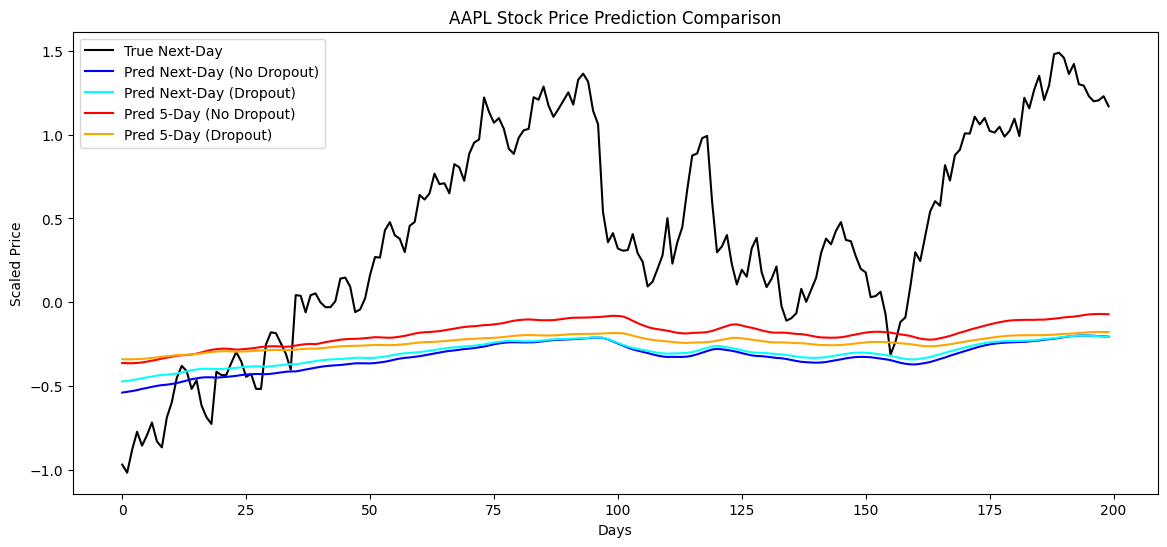

In [11]:
import yfinance as yf
from sklearn.preprocessing import StandardScaler
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, matplotlib.pyplot as plt

# ------------------------
# Download and preprocess data
# ------------------------
df = yf.download("AAPL", start="2023-01-01", end="2024-01-01")
scaler = StandardScaler()
data = scaler.fit_transform(df["Close"].values.reshape(-1,1))

seq_len = 30

def create_sequences(data, target_step=1):
    X, y = [], []
    for i in range(len(data)-seq_len-target_step+1):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len+target_step-1])
    return torch.tensor(X).float(), torch.tensor(y).float()

# Next-day data (target_step=1)
X1, y1 = create_sequences(data, target_step=1)
train_ds1 = TensorDataset(X1[:-200], y1[:-200])
test_ds1 = TensorDataset(X1[-200:], y1[-200:])
train_dl1 = DataLoader(train_ds1, batch_size=32, shuffle=True)
test_dl1 = DataLoader(test_ds1, batch_size=32)

# 5-day-ahead data (target_step=5)
X5, y5 = create_sequences(data, target_step=5)
train_ds5 = TensorDataset(X5[:-200], y5[:-200])
test_ds5 = TensorDataset(X5[-200:], y5[-200:])
train_dl5 = DataLoader(train_ds5, batch_size=32, shuffle=True)
test_dl5 = DataLoader(test_ds5, batch_size=32)

# ------------------------
# Model definition
# ------------------------
class StockLSTM(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, dropout=0.0, output_dim=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)        # out: [batch, seq_len, hidden_dim]
        out = out[:, -1, :]           # take last time step
        out = self.fc(out)            # map to output
        return out

# ------------------------
# Training function
# ------------------------
def train_model(model, train_dl, epochs=10, lr=1e-3):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            opt.step()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")
    return model

# ------------------------
# Prediction function
# ------------------------
def predict(model, loader):
    model.eval()
    preds, true = [], []
    device = "cuda" if torch.cuda.is_available() else "cpu"
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            preds.append(out.cpu())
            true.append(yb)
    preds = torch.cat(preds).numpy()
    true = torch.cat(true).numpy()
    return true, preds

# ------------------------
# Train and evaluate models
# ------------------------
# Next-day predictions
model_next_no_dropout = train_model(StockLSTM(dropout=0.0), train_dl1)
model_next_dropout = train_model(StockLSTM(dropout=0.2), train_dl1)

# 5-day-ahead predictions
model_5_no_dropout = train_model(StockLSTM(dropout=0.0), train_dl5)
model_5_dropout = train_model(StockLSTM(dropout=0.2), train_dl5)

# ------------------------
# Get predictions
# ------------------------
true_next, pred_next_no = predict(model_next_no_dropout, test_dl1)
_, pred_next_do = predict(model_next_dropout, test_dl1)
true_5, pred_5_no = predict(model_5_no_dropout, test_dl5)
_, pred_5_do = predict(model_5_dropout, test_dl5)

# ------------------------
# Plot comparisons
# ------------------------
plt.figure(figsize=(14,6))
plt.plot(true_next, label="True Next-Day", color='black')
plt.plot(pred_next_no, label="Pred Next-Day (No Dropout)", color='blue')
plt.plot(pred_next_do, label="Pred Next-Day (Dropout)", color='cyan')
plt.plot(pred_5_no, label="Pred 5-Day (No Dropout)", color='red')
plt.plot(pred_5_do, label="Pred 5-Day (Dropout)", color='orange')
plt.title("AAPL Stock Price Prediction Comparison")
plt.xlabel("Days")
plt.ylabel("Scaled Price")
plt.legend()
plt.show()


**Questions:**

1. How does the forecast horizon (1-day vs. 5-day) affect accuracy?
Accuracy decreases as the forecast horizon increases; the 5-day-ahead predictions are generally smoother but less precise than next-day predictions because errors compound further into the future.

2. Why is dropout helpful in time-series models?
Dropout helps prevent overfitting by randomly deactivating LSTM units during training, which improves generalization on unseen test data, especially in volatile time-series like stock prices.

3. What limitations does an LSTM have when modeling real financial data?
LSTMs may struggle with sudden market shocks, extreme volatility, or long-term dependencies beyond their sequence length, and they assume patterns in historical data will persist, which is often unrealistic in real financial markets.

### Problem 8: Bidirectional LSTM (10 pts)

**Goal:** Understand how bidirectional context affects sequence classification.

**Tasks:**

1. Implement the BiLSTMClassifier class.

2. Train a bidirectional LSTM on the synthetic dataset.

3. Train a unidirectional version for comparison.

4. Compute test accuracy and plot the confusion matrix.

5. Use t-SNE to visualize the final hidden state embeddings.

Epoch 1/10, Loss: 0.6980
Epoch 2/10, Loss: 0.6905
Epoch 3/10, Loss: 0.6876
Epoch 4/10, Loss: 0.6850
Epoch 5/10, Loss: 0.6821
Epoch 6/10, Loss: 0.6777
Epoch 7/10, Loss: 0.6726
Epoch 8/10, Loss: 0.6671
Epoch 9/10, Loss: 0.6610
Epoch 10/10, Loss: 0.6531
Test Accuracy: 0.5300


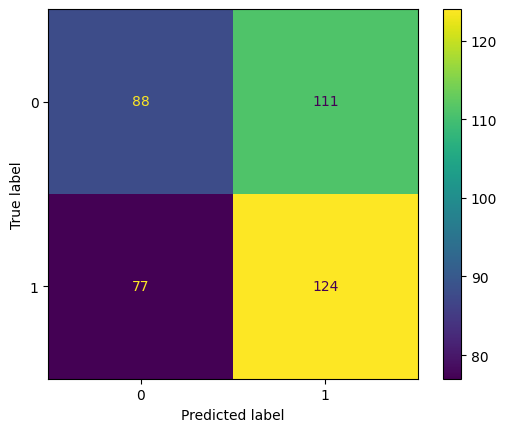

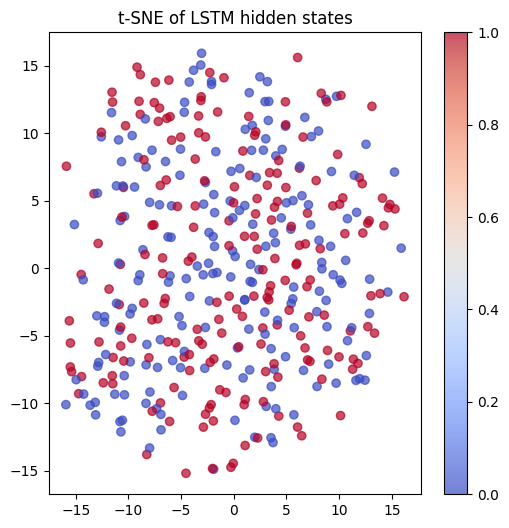

Epoch 1/10, Loss: 0.6937
Epoch 2/10, Loss: 0.6907
Epoch 3/10, Loss: 0.6886
Epoch 4/10, Loss: 0.6866
Epoch 5/10, Loss: 0.6838
Epoch 6/10, Loss: 0.6811
Epoch 7/10, Loss: 0.6765
Epoch 8/10, Loss: 0.6726
Epoch 9/10, Loss: 0.6681
Epoch 10/10, Loss: 0.6671
Test Accuracy: 0.5250


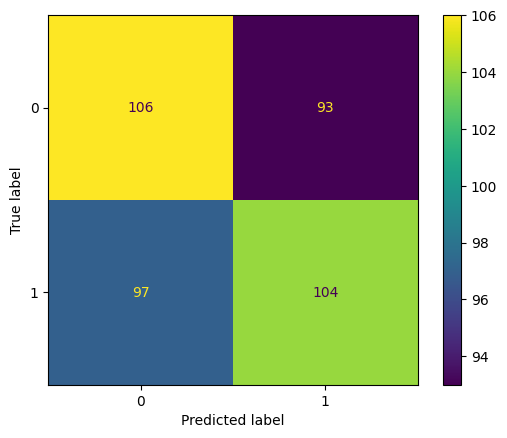

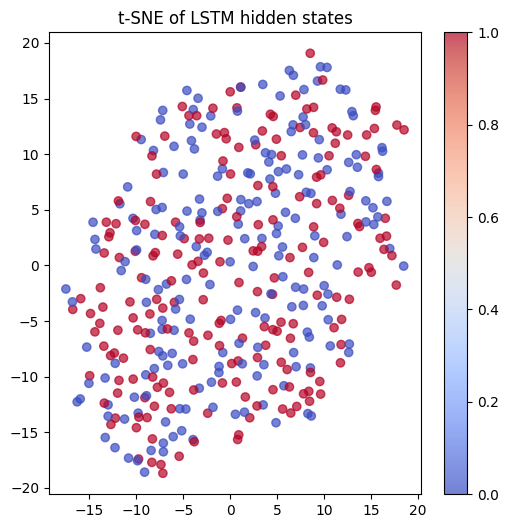

In [ ]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Synthetic datas
X = np.random.randn(2000, 30, 13)
y = np.random.randint(0, 2, 2000)
X, y = torch.tensor(X).float(), torch.tensor(y).long()
train_ds = TensorDataset(X[:1600], y[:1600])
test_ds = TensorDataset(X[1600:], y[1600:])
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

# Model
class BiLSTMClassifier(nn.Module):
    def __init__(self, input_dim=13, hidden_dim=32, num_classes=2, bidirectional=True):
        super().__init__()
        self.bidirectional = bidirectional
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=bidirectional)
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), num_classes)
    
    def forward(self, x):
        # x: [batch, seq_len, input_dim]
        out, (h_n, c_n) = self.lstm(x)
        # use the last hidden state(s)
        if self.bidirectional:
            h_last = torch.cat((h_n[-2], h_n[-1]), dim=1)  # concat forward + backward
        else:
            h_last = h_n[-1]
        logits = self.fc(h_last)
        return logits, h_last  # also return embeddings for t-SNE

# TODO: Train BiLSTM model
# TODO: Compute test accuracy and confusion matrix
# TODO: Visualize hidden embeddings using t-SNE
# Training
def train_model(model, train_dl, epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for xb, yb in train_dl:
            optimizer.zero_grad()
            logits, _ = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_dl.dataset):.4f}")
    return model

# Evaluation
def evaluate_model(model, test_ds):
    model.eval()
    X_test, y_test = test_ds[:]
    with torch.no_grad():
        logits, embeddings = model(X_test)
        preds = logits.argmax(dim=1)
        acc = (preds == y_test).float().mean().item()
        cm = confusion_matrix(y_test, preds)
    print(f"Test Accuracy: {acc:.4f}")
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.show()
    return embeddings, preds

# t-SNE
def plot_tsne(embeddings, labels):
    tsne = TSNE(n_components=2, random_state=42)
    emb_2d = tsne.fit_transform(embeddings)
    plt.figure(figsize=(6,6))
    plt.scatter(emb_2d[:,0], emb_2d[:,1], c=labels, cmap='coolwarm', alpha=0.7)
    plt.title("t-SNE of LSTM hidden states")
    plt.colorbar()
    plt.show()

# Train BiLSTM model
bilstm = BiLSTMClassifier(bidirectional=True)
bilstm = train_model(bilstm, train_dl, epochs=10)
# Evaluate BiLSTM
embeddings, preds = evaluate_model(bilstm, test_ds)
plot_tsne(embeddings.numpy(), test_ds[:][1].numpy())
# Train UniLSTM for comparison 
unilstm = BiLSTMClassifier(bidirectional=False)
unilstm = train_model(unilstm, train_dl, epochs=10)
# Evaluate UniLSTM
embeddings_uni, preds_uni = evaluate_model(unilstm, test_ds)
plot_tsne(embeddings_uni.numpy(), test_ds[:][1].numpy())


**Questions:**

1. What advantage does bidirectionality provide for sequence tasks?
Bidirectional LSTMs can access both past and future context at each time step, allowing the model to make more informed predictions than a unidirectional LSTM which can only see past information.

2. What does a well-separated t-SNE plot tell you about learned representations? A well-separated t-SNE plot indicates that the model has learned embeddings where different classes form distinct clusters, showing that the hidden states capture meaningful, discriminative features of the sequences.

3. Where might bidirectional models be useful in practice (e.g., speech or text tasks)? Bidirectional models are very useful in tasks where context from both directions matters, such as speech recognition, NLP(natural language processing), and protein sequence modeling.